# Round 1 Data Exploration

Products: **ASH_COATED_OSMIUM**, **INTARIAN_PEPPER_ROOT**  
Days: -2, -1, 0

In [4]:
import sys, os
sys.path.insert(0, os.path.join(os.path.dirname(os.getcwd()), ""))
from plotter import Plotter

DATA_DIR = "../data/round1"
days = [-2, -1, 0]

In [5]:
import pandas as pd

In [6]:
all_prices = pd.concat(
    [pd.read_csv(f"{DATA_DIR}/prices_round_1_day_{d}.csv", delimiter=";") for d in days],
    ignore_index=True,
)

osmium = all_prices[all_prices["product"] == "ASH_COATED_OSMIUM"].reset_index(drop=True)
pepper = all_prices[all_prices["product"] == "INTARIAN_PEPPER_ROOT"].reset_index(drop=True)

print(f"osmium: {len(osmium)} rows, pepper: {len(pepper)} rows")

osmium: 30000 rows, pepper: 30000 rows


In [7]:
pepper['spread'] = pepper['ask_price_1'] - pepper['bid_price_1']
osmium['spread'] = osmium['ask_price_1'] - osmium['bid_price_1']

In [8]:
# Load trades with day column (trades CSVs don't have one, so we add it)
all_trades = pd.concat(
    [pd.read_csv(f"{DATA_DIR}/trades_round_1_day_{d}.csv", delimiter=";")
       .assign(day=d)
     for d in days],
    ignore_index=True,
)

# Merge all price columns onto trades at matching (day, timestamp, product)
all_trades = all_trades.rename(columns={"symbol": "product"})
all_trades = all_trades.merge(all_prices, on=["day", "timestamp", "product"], how="left")

osmium_trades = all_trades[all_trades["product"] == "ASH_COATED_OSMIUM"].reset_index(drop=True)
pepper_trades = all_trades[all_trades["product"] == "INTARIAN_PEPPER_ROOT"].reset_index(drop=True)

print(f"osmium_trades: {len(osmium_trades)} rows, {list(osmium_trades.columns)}")
print(f"pepper_trades: {len(pepper_trades)} rows")
pepper_trades.head()

osmium_trades: 1265 rows, ['timestamp', 'buyer', 'seller', 'product', 'currency', 'price', 'quantity', 'day', 'bid_price_1', 'bid_volume_1', 'bid_price_2', 'bid_volume_2', 'bid_price_3', 'bid_volume_3', 'ask_price_1', 'ask_volume_1', 'ask_price_2', 'ask_volume_2', 'ask_price_3', 'ask_volume_3', 'mid_price', 'profit_and_loss']
pepper_trades: 1011 rows


,timestamp,buyer,seller,product,currency,price,quantity,day,bid_price_1,bid_volume_1,...,bid_price_3,bid_volume_3,ask_price_1,ask_volume_1,ask_price_2,ask_volume_2,ask_price_3,ask_volume_3,mid_price,profit_and_loss
0,1000,NaN,NaN,INTARIAN_PEPPER_ROOT,XIRECS,9995.0,7,-2,9995.0,11.0,...,NaN,NaN,10006.0,11.0,10009.0,24.0,NaN,NaN,10000.5,0.0
1,4000,NaN,NaN,INTARIAN_PEPPER_ROOT,XIRECS,10007.0,7,-2,10007.0,7.0,...,9996.0,20.0,10010.0,11.0,10012.0,20.0,NaN,NaN,10008.5,0.0
2,10500,NaN,NaN,INTARIAN_PEPPER_ROOT,XIRECS,10013.0,5,-2,10013.0,5.0,...,10002.0,22.0,10016.0,9.0,10019.0,22.0,NaN,NaN,10014.5,0.0
3,12600,NaN,NaN,INTARIAN_PEPPER_ROOT,XIRECS,10018.0,3,-2,10007.0,12.0,...,NaN,NaN,10018.0,12.0,10021.0,16.0,NaN,NaN,10012.5,0.0
4,15000,NaN,NaN,INTARIAN_PEPPER_ROOT,XIRECS,10021.0,7,-2,10009.0,12.0,...,NaN,NaN,10021.0,12.0,10023.0,25.0,NaN,NaN,10015.0,0.0


In [18]:
osmium['ask_volume_2'].value_counts()

ask_volume_2
30.0    1750
26.0    1734
25.0    1725
28.0    1717
27.0    1715
24.0    1697
22.0    1692
29.0    1686
20.0    1655
21.0    1642
23.0    1631
12.0     159
14.0     157
13.0     156
11.0     145
10.0     143
15.0     138
2.0        4
5.0        2
4.0        2
3.0        2
Name: count, dtype: int64

In [16]:
osmium[(osmium['bid_volume_1'] >= 25) & (osmium['ask_volume_1'] >= 25)].head(50)

,day,timestamp,product,bid_price_1,bid_volume_1,bid_price_2,bid_volume_2,bid_price_3,bid_volume_3,ask_price_1,ask_volume_1,ask_price_2,ask_volume_2,ask_price_3,ask_volume_3,mid_price,profit_and_loss,spread
6,-2,600,ASH_COATED_OSMIUM,9989.0,30.0,NaN,NaN,NaN,NaN,10010.0,30.0,NaN,NaN,NaN,NaN,9999.5,0.0,21.0
7,-2,700,ASH_COATED_OSMIUM,9990.0,27.0,NaN,NaN,NaN,NaN,10011.0,27.0,NaN,NaN,NaN,NaN,10000.5,0.0,21.0
82,-2,8200,ASH_COATED_OSMIUM,9994.0,30.0,NaN,NaN,NaN,NaN,10015.0,30.0,NaN,NaN,NaN,NaN,10004.5,0.0,21.0
272,-2,27200,ASH_COATED_OSMIUM,9994.0,28.0,NaN,NaN,NaN,NaN,10015.0,28.0,NaN,NaN,NaN,NaN,10004.5,0.0,21.0
329,-2,32900,ASH_COATED_OSMIUM,9994.0,30.0,NaN,NaN,NaN,NaN,10015.0,30.0,NaN,NaN,NaN,NaN,10004.5,0.0,21.0
331,-2,33100,ASH_COATED_OSMIUM,9995.0,27.0,NaN,NaN,NaN,NaN,10016.0,27.0,NaN,NaN,NaN,NaN,10005.5,0.0,21.0
349,-2,34900,ASH_COATED_OSMIUM,9994.0,26.0,NaN,NaN,NaN,NaN,10015.0,26.0,NaN,NaN,NaN,NaN,10004.5,0.0,21.0
491,-2,49100,ASH_COATED_OSMIUM,9996.0,27.0,NaN,NaN,NaN,NaN,10017.0,27.0,NaN,NaN,NaN,NaN,10006.5,0.0,21.0
516,-2,51600,ASH_COATED_OSMIUM,9997.0,30.0,NaN,NaN,NaN,NaN,10018.0,30.0,NaN,NaN,NaN,NaN,10007.5,0.0,21.0
525,-2,52500,ASH_COATED_OSMIUM,9996.0,30.0,NaN,NaN,NaN,NaN,10017.0,30.0,NaN,NaN,NaN,NaN,10006.5,0.0,21.0


In [6]:
osmium['bid_price_1_diff'] = osmium.groupby('day')['bid_price_1'].diff()

In [10]:
osmium['ask_price_1_diff'] = osmium.groupby('day')['ask_price_1'].diff()

In [7]:
osmium['bid_price_1_diff'].value_counts()

bid_price_1_diff
 0.0     13842
-1.0      2311
 1.0      2308
-2.0      1724
 2.0      1714
 3.0      1694
-3.0      1666
-5.0       337
-6.0       321
 5.0       316
 6.0       313
-9.0       182
 9.0       171
-10.0      145
 10.0      139
 8.0       102
-8.0        93
 12.0       44
-12.0       44
-4.0        38
 4.0        33
-7.0        27
 7.0        22
 11.0       18
 13.0       16
-11.0       11
-13.0       10
Name: count, dtype: int64

In [14]:
osmium[(osmium['ask_price_1_diff']  - osmium['bid_price_1_diff']<= -10)].head(50)

,day,timestamp,product,bid_price_1,bid_volume_1,bid_price_2,bid_volume_2,bid_price_3,bid_volume_3,ask_price_1,ask_volume_1,ask_price_2,ask_volume_2,ask_price_3,ask_volume_3,mid_price,profit_and_loss,bid_price_1_diff,ask_price_1_diff
9,-2,900,ASH_COATED_OSMIUM,9993.0,13.0,9990.0,30.0,NaN,NaN,9998.0,8.0,10009.0,13.0,10011.0,30.0,9995.5,0.0,0.0,-13.0
238,-2,23800,ASH_COATED_OSMIUM,9997.0,12.0,9995.0,27.0,NaN,NaN,10003.0,7.0,10013.0,12.0,10016.0,27.0,10000.0,0.0,0.0,-10.0
321,-2,32100,ASH_COATED_OSMIUM,10005.0,10.0,9993.0,22.0,NaN,NaN,10011.0,11.0,10014.0,22.0,NaN,NaN,10008.0,0.0,10.0,0.0
410,-2,41000,ASH_COATED_OSMIUM,9997.0,13.0,9994.0,24.0,NaN,NaN,10002.0,6.0,10013.0,13.0,10015.0,24.0,9999.5,0.0,1.0,-11.0
461,-2,46100,ASH_COATED_OSMIUM,10005.0,10.0,9996.0,10.0,9993.0,23.0,10014.0,23.0,NaN,NaN,NaN,NaN,10009.5,0.0,9.0,-1.0
529,-2,52900,ASH_COATED_OSMIUM,10009.0,9.0,9999.0,13.0,9996.0,25.0,10015.0,13.0,10018.0,25.0,NaN,NaN,10012.0,0.0,13.0,0.0
753,-2,75300,ASH_COATED_OSMIUM,9991.0,10.0,9989.0,27.0,NaN,NaN,10001.0,3.0,10007.0,10.0,10010.0,27.0,9996.0,0.0,2.0,-9.0
766,-2,76600,ASH_COATED_OSMIUM,10003.0,8.0,9993.0,12.0,9991.0,29.0,10009.0,12.0,10012.0,29.0,NaN,NaN,10006.0,0.0,13.0,0.0
775,-2,77500,ASH_COATED_OSMIUM,10003.0,9.0,9994.0,10.0,9991.0,20.0,10010.0,10.0,NaN,NaN,NaN,NaN,10006.5,0.0,12.0,1.0
785,-2,78500,ASH_COATED_OSMIUM,9994.0,15.0,9992.0,30.0,NaN,NaN,10000.0,6.0,NaN,NaN,NaN,NaN,9997.0,0.0,0.0,-10.0


In [14]:
osmium_trades['spread'] = osmium_trades['ask_price_1'] - osmium_trades['bid_price_1']

In [15]:
osmium_trades['spread'].value_counts()

spread
16.0    772
18.0    166
19.0    160
10.0     30
21.0     26
6.0      18
5.0      12
11.0     10
9.0       8
12.0      7
7.0       6
13.0      6
8.0       4
15.0      2
17.0      2
Name: count, dtype: int64

In [16]:
osmium['bid_volume_1'].value_counts()

bid_volume_1
14.0    3926
12.0    3876
15.0    3860
10.0    3859
13.0    3848
11.0    3775
26.0     435
30.0     430
25.0     429
29.0     426
24.0     420
27.0     402
20.0     398
23.0     395
21.0     392
22.0     381
28.0     360
4.0      270
5.0      259
2.0      216
3.0      212
9.0       72
7.0       55
6.0       53
8.0       47
Name: count, dtype: int64

In [7]:
pepper_trades['spread'] = pepper_trades['ask_price_1'] - pepper_trades['bid_price_1']

In [8]:
pepper_trades['spread'].value_counts()

spread
12.0    160
13.0    144
3.0     132
14.0    123
2.0     100
11.0     87
16.0     50
15.0     47
4.0      36
17.0     34
5.0      13
6.0      13
9.0       8
8.0       6
19.0      4
7.0       3
18.0      3
10.0      3
20.0      2
21.0      1
Name: count, dtype: int64

In [9]:
pepper_take_on_buy = pepper_trades[
    (pepper_trades['bid_price_1'] >= pepper_trades['price']) &
    (pepper_trades['ask_price_1'] - pepper_trades['price'] >= 12)
]
pepper_take_on_sell = pepper_trades[
    (pepper_trades['ask_price_1'] <= pepper_trades['price']) &
    (pepper_trades['price'] - pepper_trades['bid_price_1'] >= 12)
]
pepper_neither = pepper_trades[
    (pepper_trades['ask_price_1'] > pepper_trades['price']) &
    (pepper_trades['bid_price_1'] < pepper_trades['price'])
]
print(pepper_take_on_buy.shape, pepper_take_on_sell.shape, pepper_neither.shape)
# there is 313 possible takes on buys (meaning we would be selling)
# there are 255 takes on sells (meaning we would be buying)
# 

(313, 23) (255, 23) (1, 23)


In [10]:
pepper_take_on_buy['quantity'].sum()

np.int64(1590)

In [11]:
pepper_take_on_sell['quantity'].sum()

np.int64(1292)

In [12]:
import plotly.graph_objects as go

DAY_OFFSET = 1_000_000

buy_sorted = pepper_take_on_buy.sort_values(['day', 'timestamp']).copy()
sell_sorted = pepper_take_on_sell.sort_values(['day', 'timestamp']).copy()

buy_sorted['global_ts'] = buy_sorted['timestamp'] + (buy_sorted['day'] - buy_sorted['day'].min()) * DAY_OFFSET
sell_sorted['global_ts'] = sell_sorted['timestamp'] + (sell_sorted['day'] - sell_sorted['day'].min()) * DAY_OFFSET

buy_cum = buy_sorted.groupby('global_ts')['quantity'].sum().cumsum()
sell_cum = sell_sorted.groupby('global_ts')['quantity'].sum().cumsum()

# individual trade quantities at each timestamp
buy_per_ts = buy_sorted.groupby('global_ts')['quantity'].sum()
sell_per_ts = sell_sorted.groupby('global_ts')['quantity'].sum()

fig = go.Figure()
fig.add_trace(go.Scattergl(x=buy_cum.index, y=buy_cum.values, mode='lines', name='cumulative take on buy (sells)', line=dict(color='red')))
fig.add_trace(go.Scattergl(x=sell_cum.index, y=sell_cum.values, mode='lines', name='cumulative take on sell (buys)', line=dict(color='green')))
fig.add_trace(go.Scattergl(x=buy_cum.index, y=buy_cum.values, mode='markers', name='buy trades', marker=dict(color='red', size=5+10*(buy_per_ts/buy_per_ts.max()), opacity=0.6), customdata=buy_per_ts.values, hovertemplate='ts: %{x}<br>cumulative: %{y}<br>qty: %{customdata}<extra></extra>'))
fig.add_trace(go.Scattergl(x=sell_cum.index, y=sell_cum.values, mode='markers', name='sell trades', marker=dict(color='green', size=5+10*(sell_per_ts/sell_per_ts.max()), opacity=0.6), customdata=sell_per_ts.values, hovertemplate='ts: %{x}<br>cumulative: %{y}<br>qty: %{customdata}<extra></extra>'))
fig.update_layout(title='Pepper: cumulative take quantity over time', xaxis_title='global timestamp', yaxis_title='cumulative quantity')
fig.show(renderer='browser')

## Day -2

In [13]:
df = pd.read_csv(f"{DATA_DIR}/prices_round_1_day_-2.csv")

In [22]:
    p = Plotter(f"{DATA_DIR}/prices_round_1_day_-2.csv", f"{DATA_DIR}/trades_round_1_day_-2.csv")
    p.visualize_orderbook(product="INTARIAN_PEPPER_ROOT", ymin=9990, ymax=10500, renderer="browser")

## Day -1

In [15]:
p = Plotter(f"{DATA_DIR}/prices_round_1_day_-1.csv", f"{DATA_DIR}/trades_round_1_day_-1.csv")
p.visualize_orderbook(product="INTARIAN_PEPPER_ROOT", ymin=11000, ymax=11500, renderer="browser")

## Day 0

In [ ]:
p = Plotter(f"{DATA_DIR}/prices_round_1_day_0.csv", f"{DATA_DIR}/trades_round_1_day_0.csv")
p.visualize_orderbook(product="INTARIAN_PEPPER_ROOT", ymin=10000, ymax=10500, renderer="browser")

## All Days Merged

In [20]:
p = Plotter(
    [f"{DATA_DIR}/prices_round_1_day_{d}.csv" for d in days],
    [f"{DATA_DIR}/trades_round_1_day_{d}.csv" for d in days],
)
p.visualize_orderbook(product="INTARIAN_PEPPER_ROOT", ymin=10000, ymax=13000, renderer="browser")

In [19]:
p.visualize_orderbook(product="ASH_COATED_OSMIUM", renderer="browser", ymin = 9975, ymax = 10030)

NameError: name 'p' is not defined

In [21]:
df = pd.read_csv(f"{DATA_DIR}/prices_round_1_day_-2.csv")
p = Plotter(f"{DATA_DIR}/prices_round_1_day_-2.csv", f"{DATA_DIR}/trades_round_1_day_-2.csv")
p.visualize_orderbook(product="ASH_COATED_OSMIUM", ymin=9975, ymax=10030, renderer="browser")

## Backtest Log Visualization

In [3]:
from plotter import LogVisualizer

viz = LogVisualizer("../backtests/2026-04-16_13-42-01.log")
viz.summary()
viz.visualize(renderer="browser")

Parsed 60000 order-book rows | 3159 own trades | 21425 market trades | products: ['ASH_COATED_OSMIUM', 'INTARIAN_PEPPER_ROOT']

────────────────────────────────────────────
  ASH_COATED_OSMIUM
────────────────────────────────────────────
  Total trades  : 2034
  Buys          : 1020  | avg px 9994.39  | total vol 5538
  Sells         : 1014  | avg px 10005.45  | total vol 5538
  Gross volume  : 11076

────────────────────────────────────────────
  INTARIAN_PEPPER_ROOT
────────────────────────────────────────────
  Total trades  : 1125
  Buys          : 576  | avg px 11450.17  | total vol 2651
  Sells         : 549  | avg px 11487.56  | total vol 2427
  Gross volume  : 5078


interactive(children=(Dropdown(description='Product:', options=('ASH_COATED_OSMIUM', 'INTARIAN_PEPPER_ROOT'), …

## Backtest Log: 2026-04-15_12-52-56

In [4]:
from plotter import LogVisualizer

viz = LogVisualizer("../backtests/2026-04-16_13-42-01.log")
viz.summary()

Parsed 60000 order-book rows | 2642 own trades | 22303 market trades | products: ['ASH_COATED_OSMIUM', 'INTARIAN_PEPPER_ROOT']

────────────────────────────────────────────
  ASH_COATED_OSMIUM
────────────────────────────────────────────
  Total trades  : 1545
  Buys          : 770  | avg px 9993.86  | total vol 3914
  Sells         : 775  | avg px 10006.38  | total vol 3952
  Gross volume  : 7866

────────────────────────────────────────────
  INTARIAN_PEPPER_ROOT
────────────────────────────────────────────
  Total trades  : 1097
  Buys          : 568  | avg px 11443.00  | total vol 2584
  Sells         : 529  | avg px 11469.71  | total vol 2360
  Gross volume  : 4944


In [5]:
viz.visualize(renderer = "browser")

interactive(children=(Dropdown(description='Product:', options=('ASH_COATED_OSMIUM', 'INTARIAN_PEPPER_ROOT'), …

Baseline PARAMS (non-searched keys held fixed):
  reserve: 8  [SEARCHING]
  spread_market_thresh: 12  [SEARCHING]
  fair_take_margin: 0  [SEARCHING]
  half_spread_mm: 7

Grid search: 60 combos | product=INTARIAN_PEPPER_ROOT | days=1

  [1/60] {'reserve': 7, 'spread_market_thresh': 6, 'fair_take_margin': 0}  →  INTARIAN_PEPPER_ROOT PnL = 247,921
  [2/60] {'reserve': 7, 'spread_market_thresh': 6, 'fair_take_margin': 1}  →  INTARIAN_PEPPER_ROOT PnL = 247,921
  [3/60] {'reserve': 7, 'spread_market_thresh': 6, 'fair_take_margin': 2}  →  INTARIAN_PEPPER_ROOT PnL = 247,778
  [4/60] {'reserve': 7, 'spread_market_thresh': 7, 'fair_take_margin': 0}  →  INTARIAN_PEPPER_ROOT PnL = 248,247
  [5/60] {'reserve': 7, 'spread_market_thresh': 7, 'fair_take_margin': 1}  →  INTARIAN_PEPPER_ROOT PnL = 248,247
  [6/60] {'reserve': 7, 'spread_market_thresh': 7, 'fair_take_margin': 2}  →  INTARIAN_PEPPER_ROOT PnL = 248,136
  [7/60] {'reserve': 7, 'spread_market_thresh': 8, 'fair_take_margin': 0}  →  INTARIAN_P

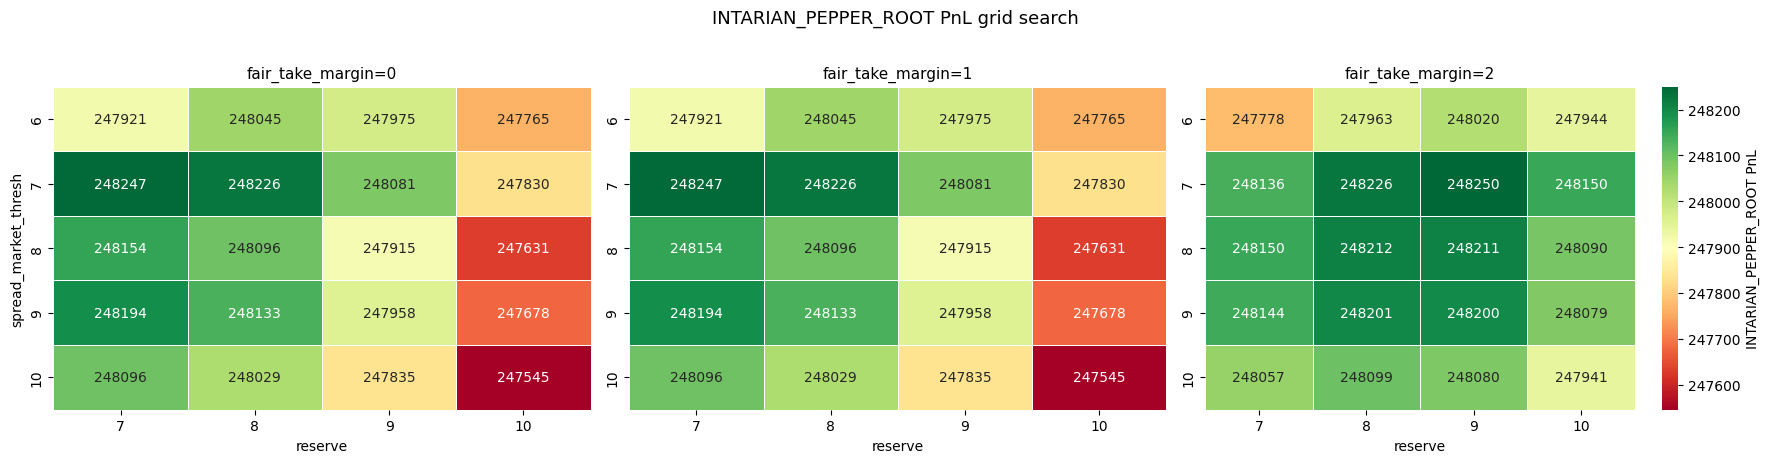

──────────────────────────────────────────────────
Top 10 for INTARIAN_PEPPER_ROOT:
──────────────────────────────────────────────────
  #1   PnL=   248,250   reserve=9, spread_market_thresh=7, fair_take_margin=2
  #2   PnL=   248,247   reserve=7, spread_market_thresh=7, fair_take_margin=0
  #3   PnL=   248,247   reserve=7, spread_market_thresh=7, fair_take_margin=1
  #4   PnL=   248,226   reserve=8, spread_market_thresh=7, fair_take_margin=0
  #5   PnL=   248,226   reserve=8, spread_market_thresh=7, fair_take_margin=1
  #6   PnL=   248,226   reserve=8, spread_market_thresh=7, fair_take_margin=2
  #7   PnL=   248,212   reserve=8, spread_market_thresh=8, fair_take_margin=2
  #8   PnL=   248,211   reserve=9, spread_market_thresh=8, fair_take_margin=2
  #9   PnL=   248,201   reserve=8, spread_market_thresh=9, fair_take_margin=2
  #10  PnL=   248,200   reserve=9, spread_market_thresh=9, fair_take_margin=2
──────────────────────────────────────────────────



In [5]:
from grid_search import grid_search

results = grid_search(
    trader_file="../TradingAlgorithms/pepper_holder_v3.py",
    days=1,                          # round 1 (all days)
    product="INTARIAN_PEPPER_ROOT",
    param_grid={
        "reserve": [7, 8, 9, 10],
        "spread_market_thresh": [6, 7, 8, 9, 10],
        "fair_take_margin": [0, 1, 2,],
    },
    top_n=10,
)


Baseline PARAMS (non-searched keys held fixed):
  base_fair: 10000  [SEARCHING]
  alpha: 0.05  [SEARCHING]
  edge: 0  [SEARCHING]
  half_width: 8  [SEARCHING]
  spike_thresh: 10  [SEARCHING]

Grid search: 108 combos | product=ASH_COATED_OSMIUM | days=1

  [1/108] {'base_fair': 10000, 'alpha': 0, 'edge': 0, 'half_width': 6, 'spike_thresh': 8}  →  ASH_COATED_OSMIUM PnL = 49,418
  [2/108] {'base_fair': 10000, 'alpha': 0, 'edge': 0, 'half_width': 6, 'spike_thresh': 10}  →  ASH_COATED_OSMIUM PnL = 49,436
  [3/108] {'base_fair': 10000, 'alpha': 0, 'edge': 0, 'half_width': 6, 'spike_thresh': 12}  →  ASH_COATED_OSMIUM PnL = 49,272
  [4/108] {'base_fair': 10000, 'alpha': 0, 'edge': 0, 'half_width': 8, 'spike_thresh': 8}  →  ASH_COATED_OSMIUM PnL = 49,418
  [5/108] {'base_fair': 10000, 'alpha': 0, 'edge': 0, 'half_width': 8, 'spike_thresh': 10}  →  ASH_COATED_OSMIUM PnL = 49,436
  [6/108] {'base_fair': 10000, 'alpha': 0, 'edge': 0, 'half_width': 8, 'spike_thresh': 12}  →  ASH_COATED_OSMIUM PnL =

ValueError: Index contains duplicate entries, cannot reshape

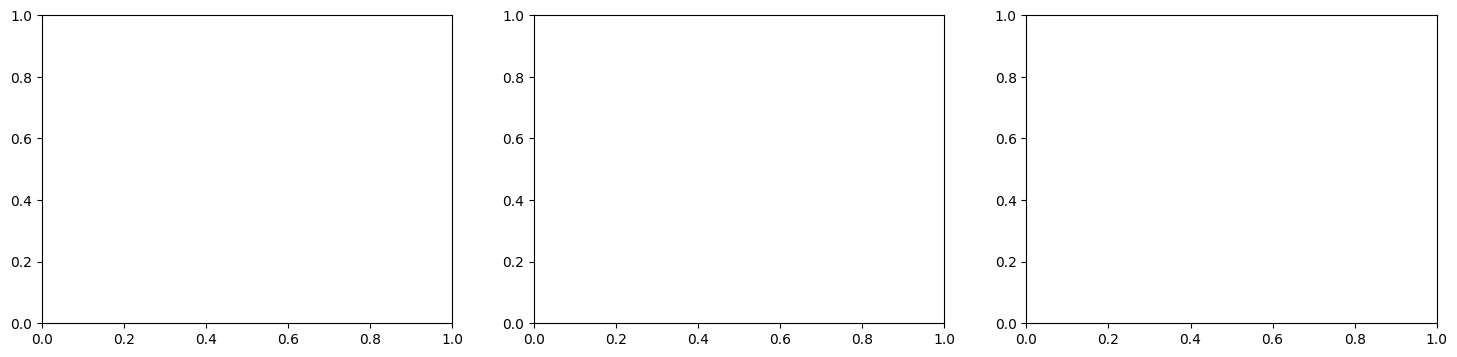

In [2]:
from grid_search import grid_search

results = grid_search(
    trader_file="../TradingAlgorithms/pepper_holder_v3.py",
    days=1,
    product="ASH_COATED_OSMIUM",
    param_grid={
        "base_fair": [10000],
        "alpha": [0, 0.05, 0.1, 0.2],
        "edge": [0, 1, 2],
        "half_width": [6, 8, 10],
        "spike_thresh": [8, 10, 12],
    },
    top_n=10,
)


## ADF Test — Osmium

In [ ]:
from statsmodels.tsa.stattools import adfuller

for day in days:
    day_data = osmium[osmium['day'] == day]['mid_price'].dropna()
    result = adfuller(day_data)
    print(f"Day {day}:")
    print(f"  ADF Statistic: {result[0]:.4f}")
    print(f"  p-value:       {result[1]:.6f}")
    print(f"  Lags used:     {result[2]}")
    print(f"  Observations:  {result[3]}")
    print(f"  Critical values:")
    for k, v in result[4].items():
        print(f"    {k}: {v:.4f}")
    print(f"  Stationary: {'Yes' if result[1] < 0.05 else 'No'}")
    print()